### 0. Import librerie ed inizalizzazione

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

np.random.seed(42)
random.seed(42)

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.svm._base')

### 0.1 Import dataset

In [74]:
# Download della versione più recente del dataset
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
print("Percorso dei file:", path)

# Caricamento del file CSV
df = pd.read_csv(path + "/breast-cancer.csv")

print("Dataset caricato con successo. Dimensioni:", df.shape)
df.head()

Percorso dei file: C:\Users\Lorenzo\.cache\kagglehub\datasets\yasserh\breast-cancer-dataset\versions\1
Dataset caricato con successo. Dimensioni: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 0.2 Analisi preliminare dataset

In [75]:
# Dimensioni del dataset
print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.\n")

# Informazioni generali
df.info()

# Statistiche descrittive per le colonne numeriche
df.describe()

# Controllo dei valori mancanti
missing_values = df.isnull().sum()
print("Valori mancanti per colonna:\n", missing_values[missing_values > 0])

Il dataset contiene 569 righe e 32 colonne.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-nu

### 0.3 Analisi target

diagnosis
B    357
M    212
Name: count, dtype: int64
Percentuali:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_14168\2234296942.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


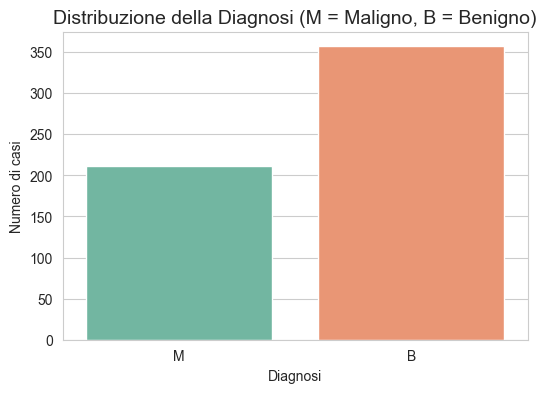

In [76]:
# Distribuzione della variabile target (valori originali: M e B)
print(df['diagnosis'].value_counts())
print(f"Percentuali:\n{df['diagnosis'].value_counts(normalize=True) * 100}")

# Countplot con le etichette originali
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribuzione della Diagnosi (M = Maligno, B = Benigno)', fontsize=14)
plt.xlabel('Diagnosi')
plt.ylabel('Numero di casi')
plt.show()

# Conversione della variabile target in numerica (M=1, B=0)
df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

### 0.4 Analisi features

In [77]:
# Separazione diagnosi da features
features = df.drop(['id', 'diagnosis'], axis=1)
diagnosis = df['diagnosis']

# Informazioni generali
features.info()
diagnosis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

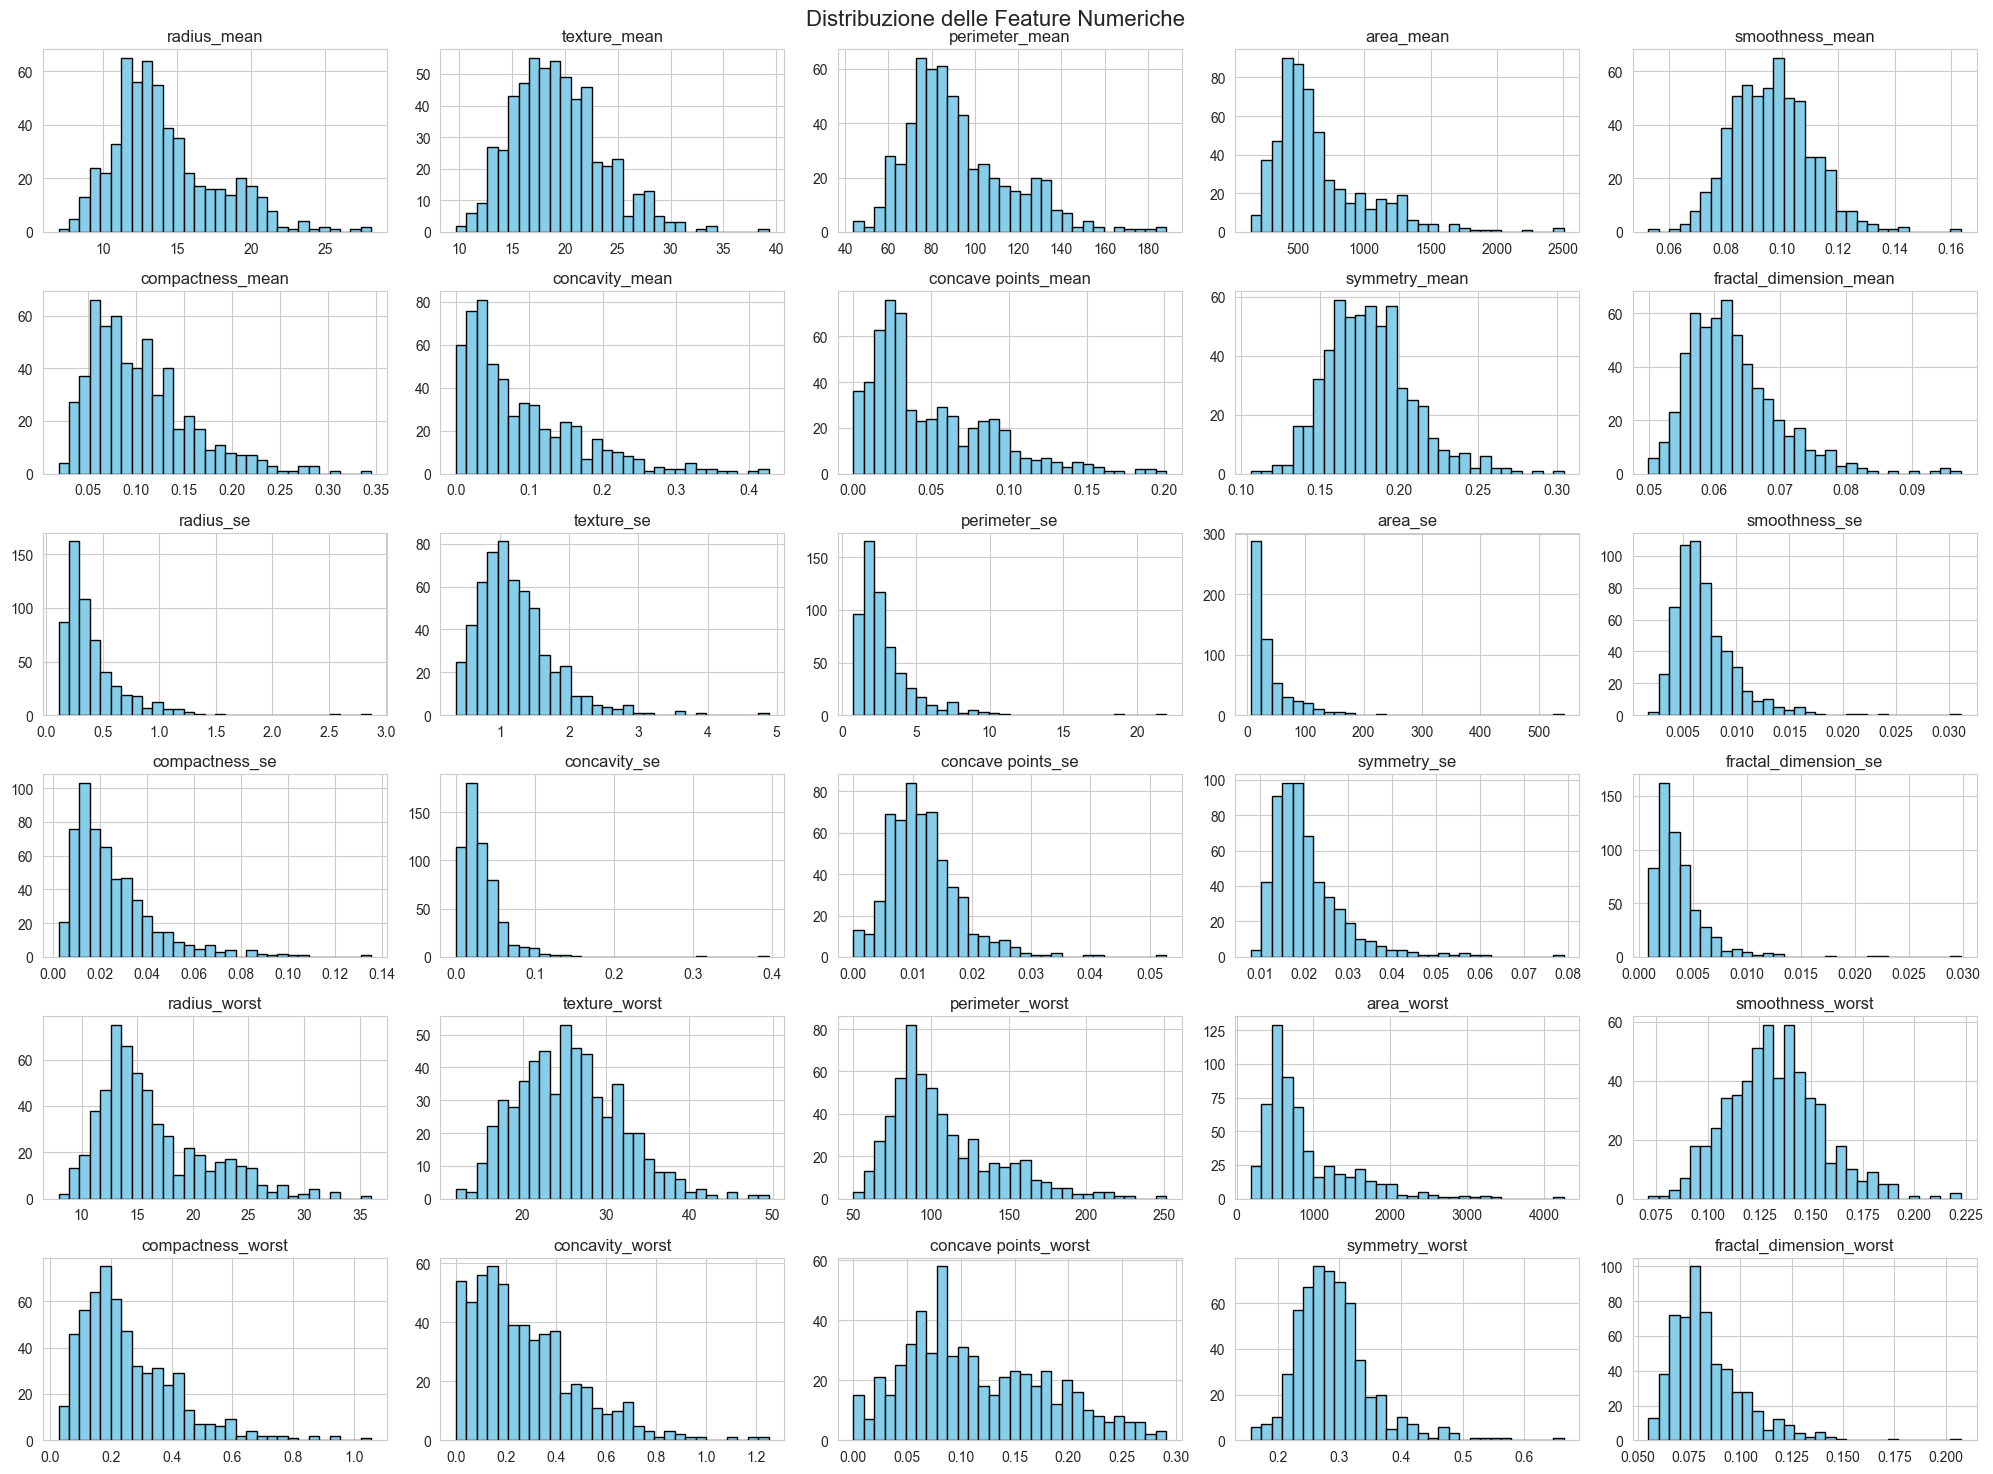

In [78]:
# Istogrammi per tutte le feature
features.hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Distribuzione delle Feature Numeriche', fontsize=16)
plt.tight_layout()
plt.show()

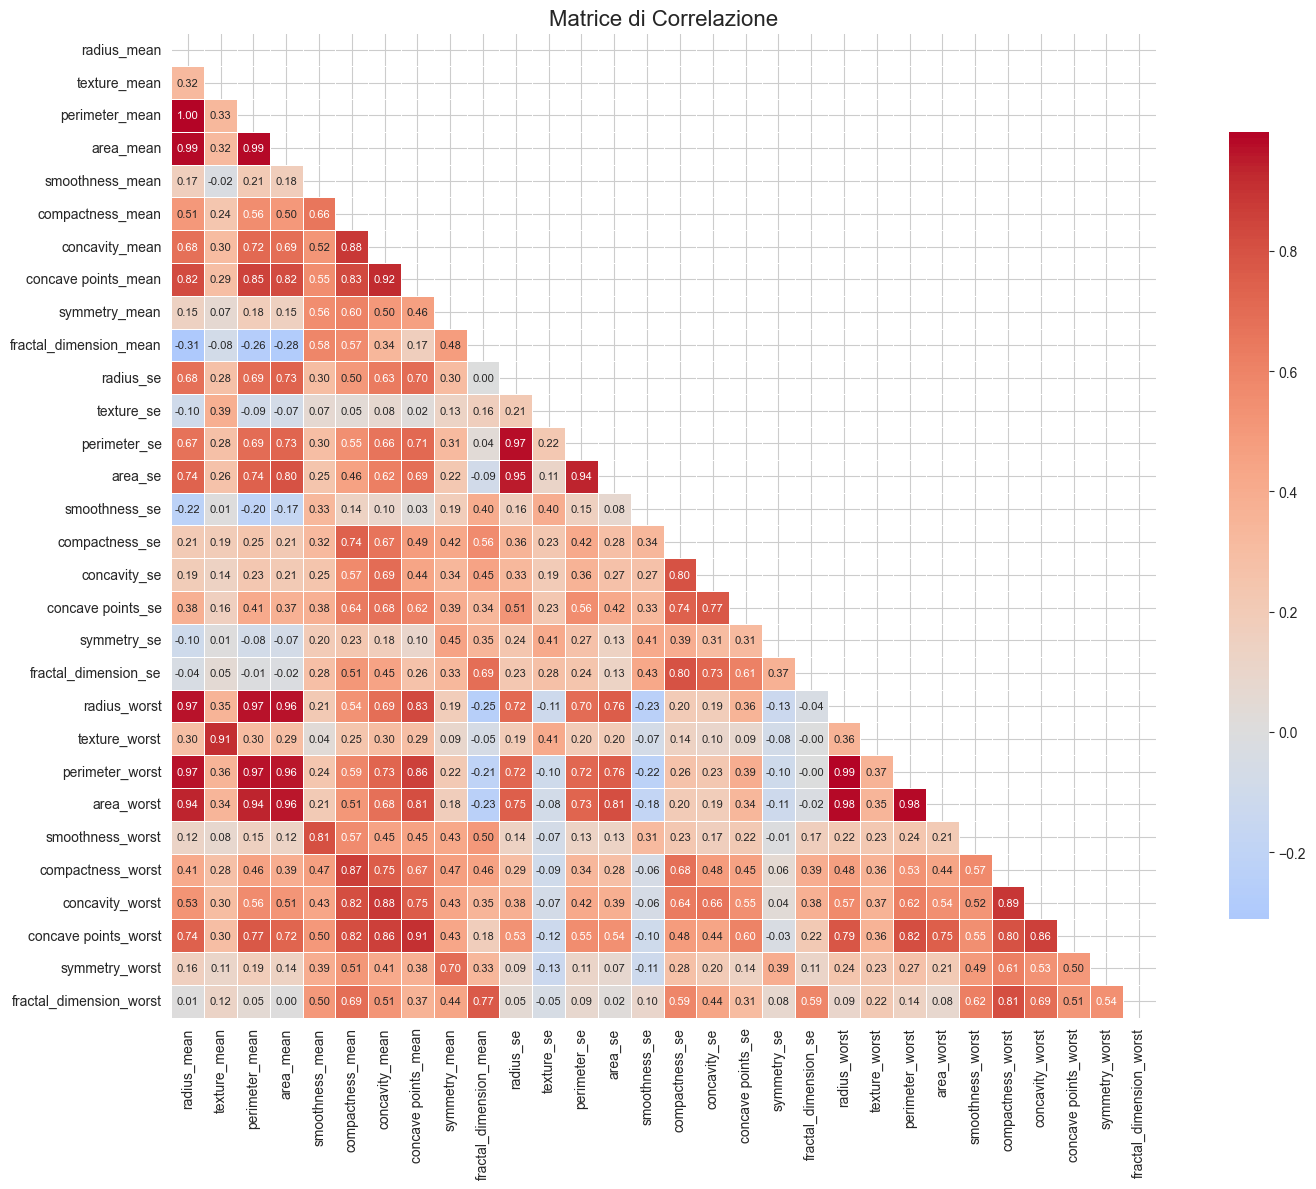

In [79]:
# Matrice di correlazione
plt.figure(figsize=(16, 12))
correlation_matrix = features.corr()

# Creazione di una maschera per il triangolo superiore e la diagonale
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Heatmap con maschera e annotazioni
sns.heatmap(correlation_matrix, 
            mask=mask,           # Nasconde triangolo superiore e diagonale
            annot=True,          # Mostra i valori numerici
            fmt='.2f',           # Formato con 2 decimali
            cmap='coolwarm',     
            center=0,            
            square=True,         
            linewidths=0.5,      
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})  # Dimensione del testo delle annotazioni

plt.title('Matrice di Correlazione', fontsize=16)
plt.tight_layout()
plt.show()

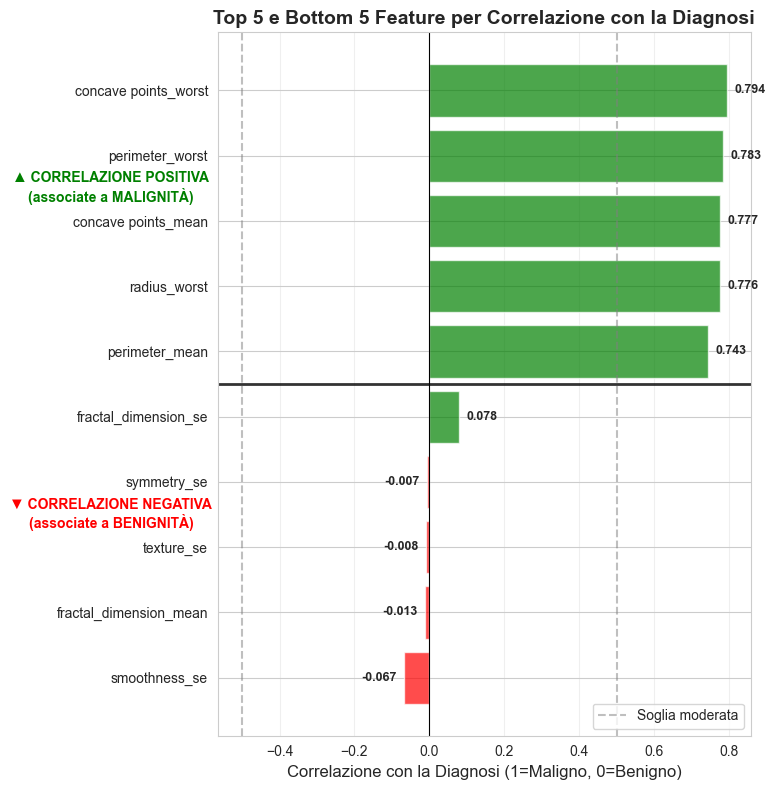

In [80]:
# Correlazione feature-target - Top 5 e Bottom 5
features_with_target = features.copy()
features_with_target['diagnosis'] = diagnosis

correlation_matrix_diag = features_with_target.corr()
corr_with_target = correlation_matrix_diag['diagnosis'].drop('diagnosis').sort_values(ascending=True)

# Selezionare top 5 (più positive) e bottom 5 (più negative)
top5 = corr_with_target.tail(5)  # Le 5 più positive
bottom5 = corr_with_target.head(5)  # Le 5 più negative

# Combinare e mantenere l'ordine (prima le negative, poi le positive)
selected_corr = pd.concat([bottom5, top5])

plt.figure(figsize=(8, 8))

# Colori: rosso per negativo, verde per positivo
colors = ['red' if x < 0 else 'green' for x in selected_corr.values]

# Barplot orizzontale
bars = plt.barh(selected_corr.index, selected_corr.values, color=colors, alpha=0.7)

# Aggiunta linea di separazione tra bottom5 e top5
# La linea viene posizionata tra il 5° e 6° elemento (indice 4.5 in termini di posizioni)
plt.axhline(y=4.5, color='black', linestyle='-', linewidth=2, alpha=0.8)

# Aggiunta etichette per identificare i due gruppi
plt.text(-0.85, 2.5, '▼ CORRELAZIONE NEGATIVA\n(associate a BENIGNITÀ)', 
         ha='center', va='center', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(-0.85, 7.5, '▲ CORRELAZIONE POSITIVA\n(associate a MALIGNITÀ)', 
         ha='center', va='center', fontsize=10, color='green', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.xlabel('Correlazione con la Diagnosi (1=Maligno, 0=Benigno)', fontsize=12)
plt.title('Top 5 e Bottom 5 Feature per Correlazione con la Diagnosi', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Soglia moderata')
plt.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

# Aggiunta dei valori sulle barre
for i, (bar, val) in enumerate(zip(bars, selected_corr.values)):
    # Posiziona il testo a destra per valori positivi, a sinistra per negativi
    if val > 0:
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
    else:
        plt.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', ha='right', va='center', fontsize=9, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 1. Preparazione dataset sporchi

In [81]:
X = features
y = diagnosis

# Dividi in train/test una volta per tutte (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 455, Test size: 114


### 1.1 Funzioni di sporcamento

In [82]:
import numpy as np
import pandas as pd
from pucktrick.labels import labels
from pucktrick.noisy import noise
from pucktrick.missing import missing
from pucktrick.outliers import outlier
from sklearn.ensemble import RandomForestClassifier

def _get_selected_features(X, y, dataset_type, k=3):
    """
    Seleziona il sottoinsieme di feature in base al tipo di analisi richiesto.
    dataset_type può assumere i valori: 'all', 'best_3', 'worst_3'
    """
    if dataset_type == 'all' or k is None or k >= len(X.columns):
        return list(X.columns)
    
    # Calcola l'importanza delle feature basandosi sui dati correnti di addestramento
    rf_temp = RandomForestClassifier(random_state=42)
    rf_temp.fit(X, y)
    
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    if dataset_type == 'best_3':
        return importance_df['feature'].head(k).tolist()
    elif dataset_type == 'worst_3':
        return importance_df['feature'].tail(k).tolist()
    return list(X.columns)

# --- Adattamento Funzioni Pucktrick con parametro dataset_type ---

def add_label_flipping(X, y, noise_ratio, label_column_name="target"):
    df = X.copy()
    df[label_column_name] = y
    strategy = {
        "affected_features": [label_column_name],
        "selection_criteria": "all",
        "percentage": noise_ratio,
        "mode": "new"
    }
    _, df_corrupted = labels(df, strategy)
    return df_corrupted[label_column_name]

def add_gaussian_noise(X, y, noise_ratio, dataset_type='all'):
    candidate_cols = _get_selected_features(X, y, dataset_type, k=3)
    n_noisy_features = max(1, int(len(candidate_cols) * noise_ratio)) if noise_ratio < 1.0 else len(candidate_cols)
    affected_cols = list(np.random.choice(candidate_cols, n_noisy_features, replace=False))
    
    if not affected_cols:
        return X.copy()
        
    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": 1.0,  
        "mode": "new",
        "perturbate_data": {"distribution": "random"}
    }
    _, X_corrupted = noise(X, strategy)
    return X_corrupted

def add_outliers(X, y, outlier_ratio, dataset_type='all'):
    affected_cols = _get_selected_features(X, y, dataset_type, k=3)
    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": outlier_ratio,
        "mode": "new"
    }
    _, X_corrupted = outlier(X, strategy)
    return X_corrupted

def add_missing_features(X, y, missing_ratio, dataset_type='all'):
    affected_cols = _get_selected_features(X, y, dataset_type, k=3)
    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": missing_ratio,
        "mode": "new"
    }
    _, X_corrupted = missing(X, strategy)
    X_corrupted[affected_cols] = X_corrupted[affected_cols].fillna(0)
    return X_corrupted

# --- Funzione di generazione centralizzata ---

def create_corrupted_dataset(X, y, corruption_type, corruption_ratio, dataset_type='all'):
    X_corr = X.copy()
    y_corr = y.copy()
    
    if corruption_type == 'label_flipping':
        y_corr = add_label_flipping(X, y, corruption_ratio)
    elif corruption_type == 'gaussian_noise':
        X_corr = add_gaussian_noise(X, y, corruption_ratio, dataset_type)
    elif corruption_type == 'outliers':
        X_corr = add_outliers(X, y, corruption_ratio, dataset_type)
    elif corruption_type == 'missing_features':
        X_corr = add_missing_features(X, y, corruption_ratio, dataset_type)
        
    return X_corr, y_corr

## 1.2 Creazione dataset

In [87]:
# Dataset pulito (nessuna corruzione)
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
y_train_clean = y_train.copy()
y_test_clean = y_test.copy()

print("Dataset pulito creato")
print(f"X_train shape: {X_train_clean.shape}")
print(f"y_train shape: {y_train_clean.shape}\n")

corruption_levels = [0.10, 0.20, 0.30, 0.40, 0.50]
dataset_types = ['all', 'best_3', 'worst_3']

# ----------------------------------------------------
# 1. LABEL FLIPPING (Calcolato solo su 'all' poiché agisce su y)
# ----------------------------------------------------
label_flipping_datasets = {'all': {}}

for level in corruption_levels:
    X_train_corr, y_train_corr = create_corrupted_dataset(
        X_train, y_train, 'label_flipping', level, dataset_type='all'
    )
    
    label_flipping_datasets['all'][level] = {
        'X_train': X_train_corr,
        'y_train': y_train_corr,
        'X_test': X_test_clean,
        'y_test': y_test_clean
    }
    
    # Verifica del flipping effettivo
    n_flipped = sum(y_train_corr != y_train)
    print(f"Label Flipping {int(level*100)}%: {n_flipped}/{len(y_train)} label cambiati ({n_flipped/len(y_train)*100:.1f}%)")
print("--> Dataset con label flipping creati\n")


# ----------------------------------------------------
# 2. GAUSSIAN NOISE (all, best_3, worst_3)
# ----------------------------------------------------
gaussian_noise_datasets = {dt: {} for dt in dataset_types}

for dt in dataset_types:
    print(f"Generazione Gaussian Noise per strategia: {dt}")
    for level in corruption_levels:
        X_train_corr, _ = create_corrupted_dataset(
            X_train, y_train, 'gaussian_noise', level, dataset_type=dt
        )
        
        gaussian_noise_datasets[dt][level] = {
            'X_train': X_train_corr,
            'y_train': y_train_clean,
            'X_test': X_test_clean,
            'y_test': y_test_clean
        }
        
        # Verifica del rumore aggiunto
        noise_magnitude = (X_train_corr - X_train).abs().mean().mean()
        print(f"  └─ Noise {int(level*100)}%: Rumore medio aggiunto = {noise_magnitude:.4f}")
print("--> Dataset con rumore gaussiano creati\n")


# ----------------------------------------------------
# 3. OUTLIER INJECTION (all, best_3, worst_3)
# ----------------------------------------------------
outlier_datasets = {dt: {} for dt in dataset_types}

for dt in dataset_types:
    print(f"Generazione Outliers per strategia: {dt}")
    for level in corruption_levels:
        X_train_corr, _ = create_corrupted_dataset(
            X_train, y_train, 'outliers', level, dataset_type=dt
        )
        
        outlier_datasets[dt][level] = {
            'X_train': X_train_corr,
            'y_train': y_train_clean,
            'X_test': X_test_clean,
            'y_test': y_test_clean
        }
        
        # Verifica outlier: conta valori > 3 std dalla media
        n_outliers = 0
        for col in X_train.columns:
            mean = X_train[col].mean()
            std = X_train[col].std()
            outliers = (X_train_corr[col] > mean + 3*std) | (X_train_corr[col] < mean - 3*std)
            n_outliers += outliers.sum()
        
        print(f"  └─ Outliers {int(level*100)}%: {n_outliers} outlier totali nel training set")
print("--> Dataset con outlier injection creati\n")


# ----------------------------------------------------
# 4. MISSING FEATURES (all, best_3, worst_3)
# ----------------------------------------------------
missing_features_datasets = {dt: {} for dt in dataset_types}

for dt in dataset_types:
    print(f"Generazione Missing Features per strategia: {dt}")
    for level in corruption_levels:
        X_train_corr, _ = create_corrupted_dataset(
            X_train, y_train, 'missing_features', level, dataset_type=dt
        )
        
        missing_features_datasets[dt][level] = {
            'X_train': X_train_corr,
            'y_train': y_train_clean,
            'X_test': X_test_clean,
            'y_test': y_test_clean
        }
        
        # Verifica valori zero aggiunti
        n_zeros = (X_train_corr == 0).sum().sum()
        total_cells = X_train_corr.shape[0] * X_train_corr.shape[1]
        print(f"  └─ Missing {int(level*100)}%: {n_zeros}/{total_cells} celle a zero ({n_zeros/total_cells*100:.1f}%)")
print("--> Dataset con missing features creati")

Dataset pulito creato
X_train shape: (455, 30)
y_train shape: (455,)

self.params in apply_injection: {}
Label Flipping 10%: 46/455 label cambiati (10.1%)
self.params in apply_injection: {}
Label Flipping 20%: 91/455 label cambiati (20.0%)
self.params in apply_injection: {}
Label Flipping 30%: 136/455 label cambiati (29.9%)
self.params in apply_injection: {}
Label Flipping 40%: 182/455 label cambiati (40.0%)
self.params in apply_injection: {}
Label Flipping 50%: 228/455 label cambiati (50.1%)
--> Dataset con label flipping creati

Generazione Gaussian Noise per strategia: all
  └─ Noise 10%: Rumore medio aggiunto = 0.0564
  └─ Noise 20%: Rumore medio aggiunto = 8.7861
  └─ Noise 30%: Rumore medio aggiunto = 1.4822
  └─ Noise 40%: Rumore medio aggiunto = 36.9602
  └─ Noise 50%: Rumore medio aggiunto = 31.8255
Generazione Gaussian Noise per strategia: best_3
  └─ Noise 10%: Rumore medio aggiunto = 51.5538
  └─ Noise 20%: Rumore medio aggiunto = 49.0169
  └─ Noise 30%: Rumore medio aggiun

In [88]:
def standardize_dataset(X_train, X_test):
    """
    Standardizza i dati usando la media e std del training set
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Riporta in DataFrame
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_test_scaled, scaler


# Raccolta di tutti i dataset corrotti strutturata con le nuove strategie
all_corrupted_datasets = {
    'clean': {
        'X_train': X_train_clean,
        'X_test': X_test_clean,
        'y_train': y_train_clean,
        'y_test': y_test_clean
    },
    'label_flipping': label_flipping_datasets,      # Contiene solo la chiave 'all'
    'gaussian_noise': gaussian_noise_datasets,      # Contiene 'all', 'best_3', 'worst_3'
    'outliers': outlier_datasets,                  # Contiene 'all', 'best_3', 'worst_3'
    'missing_features': missing_features_datasets   # Contiene 'all', 'best_3', 'worst_3'
}

# Inizializzazione della struttura per i dataset standardizzati
standardized_datasets = {}

# 1. Dataset pulito (Invariato)
X_train_s, X_test_s, _ = standardize_dataset(X_train_clean, X_test_clean)
standardized_datasets['clean'] = {
    'X_train': X_train_s,
    'X_test': X_test_s,
    'y_train': y_train_clean,
    'y_test': y_test_clean
}

# 2. Dataset corrotti (Ciclo aggiornato su due livelli: strategia e livello)
for corr_type in ['label_flipping', 'gaussian_noise', 'outliers', 'missing_features']:
    standardized_datasets[corr_type] = {}
    
    # Iteriamo su tutte le strategie disponibili per questo tipo di corruzione (es: 'all', 'best_3', etc.)
    for dataset_type, levels_dict in all_corrupted_datasets[corr_type].items():
        standardized_datasets[corr_type][dataset_type] = {}
        
        # Iteriamo su ciascun livello di corruzione della strategia corrente
        for level, data in levels_dict.items():
            X_train_s, X_test_s, _ = standardize_dataset(data['X_train'], data['X_test'])
            
            standardized_datasets[corr_type][dataset_type][level] = {
                'X_train': X_train_s,
                'X_test': X_test_s,
                'y_train': data['y_train'],
                'y_test': data['y_test']
            }

print("Tutti i dataset standardizzati con successo!")

Tutti i dataset standardizzati con successo!


# 2. Addestramento SVM

In [90]:
results = {
    'dataset_type': [],
    'corruption_level': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

def evaluate_svm(X_train, y_train, X_test, y_test, dataset_name, corruption_level=0):    
    """    Addestra SVM e restituisce metriche    """
    # Addestra SVM con kernel lineare (ottimo per questo dataset)
    svm = SVC(kernel='linear', random_state=42, C=1.0)
    svm.fit(X_train, y_train)
    
    # Predizioni
    y_pred = svm.predict(X_test)
    
    # Metriche
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # Salva risultati
    results['dataset_type'].append(dataset_name)
    results['corruption_level'].append(corruption_level)
    results['accuracy'].append(acc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1_score'].append(f1)
    
    print(f"{dataset_name} (corruption={corruption_level}): Acc={acc:.4f}, F1={f1:.4f}")
    
    return svm, y_pred


In [91]:

# 1. Dataset Pulito
clean_data = standardized_datasets['clean']
svm_clean, pred_clean = evaluate_svm(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# 2. Label Flipping (Agisce solo su y, usiamo la strategia 'all')
for level in corruption_levels:
    data = standardized_datasets['label_flipping']['all'][level]
    svm_lf, _ = evaluate_svm(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# 3. Gaussian Noise (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['gaussian_noise'][strat][level]
        svm_gn, _ = evaluate_svm(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'gaussian_noise_{strat}', level
        )

# 4. Outliers (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['outliers'][strat][level]
        svm_out, _ = evaluate_svm(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'outliers_{strat}', level
        )

# 5. Missing Features (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['missing_features'][strat][level]
        svm_mf, _ = evaluate_svm(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'missing_features_{strat}', level
        )

clean (corruption=0): Acc=0.9649, F1=0.9500
label_flipping (corruption=0.1): Acc=0.9211, F1=0.8889
label_flipping (corruption=0.2): Acc=0.9649, F1=0.9512
label_flipping (corruption=0.3): Acc=0.8684, F1=0.7945
label_flipping (corruption=0.4): Acc=0.8070, F1=0.6944
label_flipping (corruption=0.5): Acc=0.4649, F1=0.4404
gaussian_noise_all (corruption=0.1): Acc=0.9649, F1=0.9512
gaussian_noise_all (corruption=0.2): Acc=0.9561, F1=0.9367
gaussian_noise_all (corruption=0.3): Acc=0.9825, F1=0.9762
gaussian_noise_all (corruption=0.4): Acc=0.9737, F1=0.9647
gaussian_noise_all (corruption=0.5): Acc=0.9561, F1=0.9367
gaussian_noise_best_3 (corruption=0.1): Acc=0.9561, F1=0.9367
gaussian_noise_best_3 (corruption=0.2): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.3): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.4): Acc=0.9737, F1=0.9630
gaussian_noise_best_3 (corruption=0.5): Acc=0.9561, F1=0.9367
gaussian_noise_worst_3 (corruption=0.1): Acc=0.9737, F1=0.9630
gaussian_nois

In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convertiamo il dizionario dei risultati in un DataFrame di Pandas
results_df = pd.DataFrame(results)

# 2. Inizializziamo la griglia dei subplot (2x2 per le 4 metriche)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Estraiamo tutti i tipi di dataset unici generati dinamici ('clean', 'gaussian_noise_all', ecc.)
unique_datasets = results_df['dataset_type'].unique()

# Definiamo una lista di marker unici per differenziare meglio le linee all'interno dello stesso grafico
markers_list = ['o', 's', '^', 'D', 'v', '<', '>', 'X', 'P', '*']
marker_mapping = {ds: markers_list[i % len(markers_list)] for i, ds in enumerate(unique_datasets)}

# 3. Popoliamo i grafici ciclando sulle metriche
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    for dataset in unique_datasets:
        # Selezioniamo il sottoinsieme di dati e ordiniamo per livello di corruzione
        subset = results_df[results_df['dataset_type'] == dataset].sort_values('corruption_level')
        
        # Disegniamo la linea per il dataset corrente
        ax.plot(
            subset['corruption_level'], 
            subset[metric], 
            marker=marker_mapping[dataset], 
            label=dataset, 
            linewidth=2, 
            markersize=6
        )
    
    # Configurazione dettagliata degli assi e delle etichette
    ax.set_xlabel('Corruption Level', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'SVM {title} vs Corruption Level', fontsize=12)
    ax.legend(fontsize=8, loc='best', frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Includiamo lo 0 sull'asse X per mostrare il punto del dataset pulito ('clean')
    ax.set_xticks([0] + corruption_levels)
    ax.set_ylim([0, 1.05])

# Ottimizzazione del layout per evitare sovrapposizioni di etichette e testi
plt.tight_layout()

# Salvataggio del grafico come file immagine (senza usare plt.show() o fig.figure())
plt.savefig('svm_metrics_corruption_comparison.png', dpi=300, bbox_inches='tight')
print("Grafico di confronto salvato con successo come 'svm_metrics_corruption_comparison.png'")

Grafico di confronto salvato con successo come 'svm_metrics_corruption_comparison.png'


## 3. Random Forest

In [94]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Inizializzazione della struttura dati per i risultati del Random Forest
results_rf = {
    'dataset_type': [],
    'corruption_level': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

def evaluate_random_forest(X_train, y_train, X_test, y_test, dataset_name, corruption_level=0):    
    """    Addestra Random Forest e restituisce metriche    """
    # Addestra Random Forest con 100 alberi
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predizioni
    y_pred = rf.predict(X_test)
    
    # Calcolo delle Metriche
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # Salva i risultati nel dizionario dedicato a Random Forest
    results_rf['dataset_type'].append(dataset_name)
    results_rf['corruption_level'].append(corruption_level)
    results_rf['accuracy'].append(acc)
    results_rf['precision'].append(prec)
    results_rf['recall'].append(rec)
    results_rf['f1_score'].append(f1)
    
    print(f"{dataset_name} (corruption={corruption_level}): Acc={acc:.4f}, F1={f1:.4f}")
    
    return rf, y_pred

# ----------------------------------------------------
# ESECUZIONE DELLA VALUTAZIONE SU TUTTI I DATASET
# ----------------------------------------------------

# 1. Dataset Pulito (Baseline)
clean_data = standardized_datasets['clean']
rf_clean, pred_clean_rf = evaluate_random_forest(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# 2. Label Flipping (Strategia 'all' su y)
for level in corruption_levels:
    data = standardized_datasets['label_flipping']['all'][level]
    rf_lf, _ = evaluate_random_forest(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# 3. Gaussian Noise (Strategie: all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['gaussian_noise'][strat][level]
        rf_gn, _ = evaluate_random_forest(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'gaussian_noise_{strat}', level
        )

# 4. Outliers (Strategie: all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['outliers'][strat][level]
        rf_out, _ = evaluate_random_forest(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'outliers_{strat}', level
        )

# 5. Missing Features (Strategie: all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['missing_features'][strat][level]
        rf_mf, _ = evaluate_random_forest(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'missing_features_{strat}', level
        )

print("\n--> Tutti i dataset sono stati valutati con Random Forest!")

clean (corruption=0): Acc=0.9737, F1=0.9630
label_flipping (corruption=0.1): Acc=0.9649, F1=0.9500
label_flipping (corruption=0.2): Acc=0.9298, F1=0.9048
label_flipping (corruption=0.3): Acc=0.9035, F1=0.8571
label_flipping (corruption=0.4): Acc=0.7368, F1=0.6154
label_flipping (corruption=0.5): Acc=0.4737, F1=0.4118
gaussian_noise_all (corruption=0.1): Acc=0.9737, F1=0.9630
gaussian_noise_all (corruption=0.2): Acc=0.9649, F1=0.9500
gaussian_noise_all (corruption=0.3): Acc=0.9474, F1=0.9250
gaussian_noise_all (corruption=0.4): Acc=0.9561, F1=0.9383
gaussian_noise_all (corruption=0.5): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.1): Acc=0.9649, F1=0.9512
gaussian_noise_best_3 (corruption=0.2): Acc=0.9649, F1=0.9512
gaussian_noise_best_3 (corruption=0.3): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.4): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.5): Acc=0.9649, F1=0.9500
gaussian_noise_worst_3 (corruption=0.1): Acc=0.9649, F1=0.9500
gaussian_nois

In [95]:
# ----------------------------------------------------
# VALUTAZIONE RANDOM FOREST CON STRATEGIE (all, best_3, worst_3)
# ----------------------------------------------------

# 1. Clean dataset (Baseline)
clean_data = standardized_datasets['clean']
rf_clean, pred_clean = evaluate_random_forest(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# 2. Label flipping (Agisce solo sulle etichette, usiamo la strategia 'all')
for level in corruption_levels:
    data = standardized_datasets['label_flipping']['all'][level]
    rf_lf, _ = evaluate_random_forest(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# 3. Gaussian noise (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['gaussian_noise'][strat][level]
        rf_gn, _ = evaluate_random_forest(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'gaussian_noise_{strat}', level
        )

# 4. Outliers (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['outliers'][strat][level]
        rf_out, _ = evaluate_random_forest(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'outliers_{strat}', level
        )

# 5. Missing features (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['missing_features'][strat][level]
        rf_mf, _ = evaluate_random_forest(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'missing_features_{strat}', level
        )

print("\n--> Processo completato! Tutti i dataset corrotti sono stati valutati con Random Forest.")

clean (corruption=0): Acc=0.9737, F1=0.9630
label_flipping (corruption=0.1): Acc=0.9649, F1=0.9500
label_flipping (corruption=0.2): Acc=0.9298, F1=0.9048
label_flipping (corruption=0.3): Acc=0.9035, F1=0.8571
label_flipping (corruption=0.4): Acc=0.7368, F1=0.6154
label_flipping (corruption=0.5): Acc=0.4737, F1=0.4118
gaussian_noise_all (corruption=0.1): Acc=0.9737, F1=0.9630
gaussian_noise_all (corruption=0.2): Acc=0.9649, F1=0.9500
gaussian_noise_all (corruption=0.3): Acc=0.9474, F1=0.9250
gaussian_noise_all (corruption=0.4): Acc=0.9561, F1=0.9383
gaussian_noise_all (corruption=0.5): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.1): Acc=0.9649, F1=0.9512
gaussian_noise_best_3 (corruption=0.2): Acc=0.9649, F1=0.9512
gaussian_noise_best_3 (corruption=0.3): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.4): Acc=0.9649, F1=0.9500
gaussian_noise_best_3 (corruption=0.5): Acc=0.9649, F1=0.9500
gaussian_noise_worst_3 (corruption=0.1): Acc=0.9649, F1=0.9500
gaussian_nois

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convertiamo il dizionario dei risultati di Random Forest in un DataFrame
# Utilizziamo 'results_rf' definito nel blocco precedente
results_df_rf = pd.DataFrame(results_rf)

# 2. Inizializziamo la griglia dei subplot (2x2 per le 4 metriche)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Estraiamo tutti i tipi di dataset unici generati ('clean', 'gaussian_noise_all', ecc.)
unique_datasets = results_df_rf['dataset_type'].unique()

# Mappatura dinamica dei marker per rendere distinguibili le linee sul grafico
markers_list = ['o', 's', '^', 'D', 'v', '<', '>', 'X', 'P', '*']
marker_mapping = {ds: markers_list[i % len(markers_list)] for i, ds in enumerate(unique_datasets)}

# 3. Popoliamo i grafici ciclando sulle metriche
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    for dataset in unique_datasets:
        # Selezioniamo il sottoinsieme e ordiniamo i dati per livello di corruzione
        subset = results_df_rf[results_df_rf['dataset_type'] == dataset].sort_values('corruption_level')
        
        # Disegniamo la linea per il dataset corrente
        ax.plot(
            subset['corruption_level'], 
            subset[metric], 
            marker=marker_mapping[dataset], 
            label=dataset, 
            linewidth=2, 
            markersize=6
        )
    
    # Configurazione assi ed etichette
    ax.set_xlabel('Corruption Level', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Random Forest {title} vs Corruption Level', fontsize=12)
    ax.legend(fontsize=8, loc='best', frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Includiamo lo 0 sull'asse X per mostrare il punto di baseline pulito ('clean')
    ax.set_xticks([0] + corruption_levels)
    ax.set_ylim([0, 1.05])

# Ottimizzazione del layout per evitare sovrapposizioni
plt.tight_layout()

# Salvataggio del grafico come file immagine
plt.savefig('random_forest_metrics_corruption_comparison.png', dpi=300, bbox_inches='tight')
print("Grafico di confronto salvato con successo come 'random_forest_metrics_corruption_comparison.png'")

Grafico di confronto salvato con successo come 'random_forest_metrics_corruption_comparison.png'


## Rete Neurale

In [98]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Inizializzazione della struttura dati dedicata per i risultati della MLP
results_mlp = {
    'dataset_type': [],
    'corruption_level': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

def evaluate_mlp(X_train, y_train, X_test, y_test, dataset_name, corruption_level=0):
    """
    Addestra una MLP con architettura semplice + early stopping.
    """
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),   # due layer nascosti
        activation='relu',
        alpha=0.0001,                  # regolarizzazione L2 (weight decay)
        early_stopping=True,           # ferma se validation loss non migliora
        validation_fraction=0.1,
        random_state=42,
        max_iter=200
    )
    mlp.fit(X_train, y_train)
    
    y_pred = mlp.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    
    # Salva i risultati nel dizionario dedicato a MLP
    results_mlp['dataset_type'].append(dataset_name)
    results_mlp['corruption_level'].append(corruption_level)
    results_mlp['accuracy'].append(acc)
    results_mlp['precision'].append(prec)
    results_mlp['recall'].append(rec)
    results_mlp['f1_score'].append(f1)
    
    print(f"{dataset_name} (corruption={corruption_level}): Acc={acc:.4f}, F1={f1:.4f}")
    
    return mlp, y_pred

# ----------------------------------------------------
# ESECUZIONE DELLA VALUTAZIONE SU TUTTI I DATASET (MLP)
# ----------------------------------------------------

# 1. Dataset Pulito (Baseline)
clean_data = standardized_datasets['clean']
mlp_clean, pred_clean_mlp = evaluate_mlp(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# 2. Label Flipping (Strategia 'all' applicata a y)
for level in corruption_levels:
    data = standardized_datasets['label_flipping']['all'][level]
    mlp_lf, _ = evaluate_mlp(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# 3. Gaussian Noise (Strategie: all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['gaussian_noise'][strat][level]
        mlp_gn, _ = evaluate_mlp(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'gaussian_noise_{strat}', level
        )

# 4. Outliers (Strategie: all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['outliers'][strat][level]
        mlp_out, _ = evaluate_mlp(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'outliers_{strat}', level
        )

# 5. Missing Features (Strategie: all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['missing_features'][strat][level]
        mlp_mf, _ = evaluate_mlp(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'missing_features_{strat}', level
        )

print("\n--> Tutti i dataset corrotti sono stati valutati con successo tramite MLP!")

clean (corruption=0): Acc=0.8596, F1=0.7714
label_flipping (corruption=0.1): Acc=0.9386, F1=0.9091
label_flipping (corruption=0.2): Acc=0.9298, F1=0.9048
label_flipping (corruption=0.3): Acc=0.8947, F1=0.8378
label_flipping (corruption=0.4): Acc=0.7105, F1=0.4762
label_flipping (corruption=0.5): Acc=0.5702, F1=0.3636
gaussian_noise_all (corruption=0.1): Acc=0.9474, F1=0.9250
gaussian_noise_all (corruption=0.2): Acc=0.8772, F1=0.8056
gaussian_noise_all (corruption=0.3): Acc=0.8596, F1=0.7714
gaussian_noise_all (corruption=0.4): Acc=0.9561, F1=0.9383
gaussian_noise_all (corruption=0.5): Acc=0.9561, F1=0.9412
gaussian_noise_best_3 (corruption=0.1): Acc=0.8684, F1=0.7887
gaussian_noise_best_3 (corruption=0.2): Acc=0.8772, F1=0.8056
gaussian_noise_best_3 (corruption=0.3): Acc=0.8509, F1=0.7536
gaussian_noise_best_3 (corruption=0.4): Acc=0.8947, F1=0.8421
gaussian_noise_best_3 (corruption=0.5): Acc=0.8772, F1=0.8056
gaussian_noise_worst_3 (corruption=0.1): Acc=0.8596, F1=0.7714
gaussian_nois

In [99]:
# ----------------------------------------------------
# VALUTAZIONE MLP CON STRATEGIE (all, best_3, worst_3)
# ----------------------------------------------------

# 1. Clean dataset (Baseline)
clean_data = standardized_datasets['clean']
mlp_clean, pred_clean_mlp = evaluate_mlp(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# 2. Label flipping (Agisce solo sulle etichette, usiamo la strategia 'all')
for level in corruption_levels:
    data = standardized_datasets['label_flipping']['all'][level]
    mlp_lf, _ = evaluate_mlp(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# 3. Gaussian noise (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['gaussian_noise'][strat][level]
        mlp_gn, _ = evaluate_mlp(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'gaussian_noise_{strat}', level
        )

# 4. Outliers (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['outliers'][strat][level]
        mlp_out, _ = evaluate_mlp(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'outliers_{strat}', level
        )

# 5. Missing features (all, best_3, worst_3)
for strat in ['all', 'best_3', 'worst_3']:
    for level in corruption_levels:
        data = standardized_datasets['missing_features'][strat][level]
        mlp_mf, _ = evaluate_mlp(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            f'missing_features_{strat}', level
        )

print("\n--> Processo completato! Tutti i dataset corrotti sono stati valutati con la rete neurale MLP.")

clean (corruption=0): Acc=0.8596, F1=0.7714
label_flipping (corruption=0.1): Acc=0.9386, F1=0.9091
label_flipping (corruption=0.2): Acc=0.9298, F1=0.9048
label_flipping (corruption=0.3): Acc=0.8947, F1=0.8378
label_flipping (corruption=0.4): Acc=0.7105, F1=0.4762
label_flipping (corruption=0.5): Acc=0.5702, F1=0.3636
gaussian_noise_all (corruption=0.1): Acc=0.9474, F1=0.9250
gaussian_noise_all (corruption=0.2): Acc=0.8772, F1=0.8056
gaussian_noise_all (corruption=0.3): Acc=0.8596, F1=0.7714
gaussian_noise_all (corruption=0.4): Acc=0.9561, F1=0.9383
gaussian_noise_all (corruption=0.5): Acc=0.9561, F1=0.9412
gaussian_noise_best_3 (corruption=0.1): Acc=0.8684, F1=0.7887
gaussian_noise_best_3 (corruption=0.2): Acc=0.8772, F1=0.8056
gaussian_noise_best_3 (corruption=0.3): Acc=0.8509, F1=0.7536
gaussian_noise_best_3 (corruption=0.4): Acc=0.8947, F1=0.8421
gaussian_noise_best_3 (corruption=0.5): Acc=0.8772, F1=0.8056
gaussian_noise_worst_3 (corruption=0.1): Acc=0.8596, F1=0.7714
gaussian_nois

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convertiamo il dizionario dei risultati della MLP in un DataFrame
# Utilizziamo 'results_mlp' definito nel blocco precedente
results_df_mlp = pd.DataFrame(results_mlp)

# 2. Inizializziamo la griglia dei subplot (2x2 per le 4 metriche)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Estraiamo tutti i tipi di dataset unici generati ('clean', 'gaussian_noise_all', ecc.)
unique_datasets = results_df_mlp['dataset_type'].unique()

# Mappatura dinamica dei marker per rendere ben distinguibili le linee sul grafico
markers_list = ['o', 's', '^', 'D', 'v', '<', '>', 'X', 'P', '*']
marker_mapping = {ds: markers_list[i % len(markers_list)] for i, ds in enumerate(unique_datasets)}

# 3. Popoliamo i grafici ciclando sulle metriche
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    for dataset in unique_datasets:
        # Selezioniamo il sottoinsieme e ordiniamo i dati per livello di corruzione
        subset = results_df_mlp[results_df_mlp['dataset_type'] == dataset].sort_values('corruption_level')
        
        # Disegniamo la linea per il dataset corrente
        ax.plot(
            subset['corruption_level'], 
            subset[metric], 
            marker=marker_mapping[dataset], 
            label=dataset, 
            linewidth=2, 
            markersize=6
        )
    
    # Configurazione assi ed etichette
    ax.set_xlabel('Corruption Level', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Neural Network (MLP) {title} vs Corruption Level', fontsize=12)
    ax.legend(fontsize=8, loc='best', frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Includiamo lo 0 sull'asse X per mostrare il punto di baseline pulito ('clean')
    ax.set_xticks([0] + corruption_levels)
    ax.set_ylim([0, 1.05])

# Ottimizzazione del layout per evitare sovrapposizioni di testo
plt.tight_layout()

# Salvataggio del grafico come file immagine (senza usare plt.show())
plt.savefig('mlp_metrics_corruption_comparison.png', dpi=300, bbox_inches='tight')
print("Grafico di confronto salvato con successo come 'mlp_metrics_corruption_comparison.png'")

Grafico di confronto salvato con successo come 'mlp_metrics_corruption_comparison.png'
